# 第27章: 時系列解析

## 学習目標
- 定常性と自己相関関数を理解する
- AR, MA, ARMA, ARIMAモデルを適用できる
- Box-Jenkins法を実行できる
- 予測を行える
- スペクトル分析の基礎を理解する

## 📋 学習メタ情報

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, signal
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 27.1 定常性と自己相関関数

### 弱定常性
1. 平均が一定: $E[Y_t] = \mu$
2. 分散が一定: $\text{Var}(Y_t) = \sigma^2$
3. 自己共分散が時差のみに依存: $\text{Cov}(Y_t, Y_{t+h}) = \gamma_h$

### 自己相関関数 (ACF)
$$\rho_h = \frac{\gamma_h}{\gamma_0} = \frac{\text{Cov}(Y_t, Y_{t+h})}{\text{Var}(Y_t)}$$

### 偏自己相関関数 (PACF)
$Y_t$ と $Y_{t+h}$ の相関から中間の変数の影響を除いたもの

定常性と自己相関関数


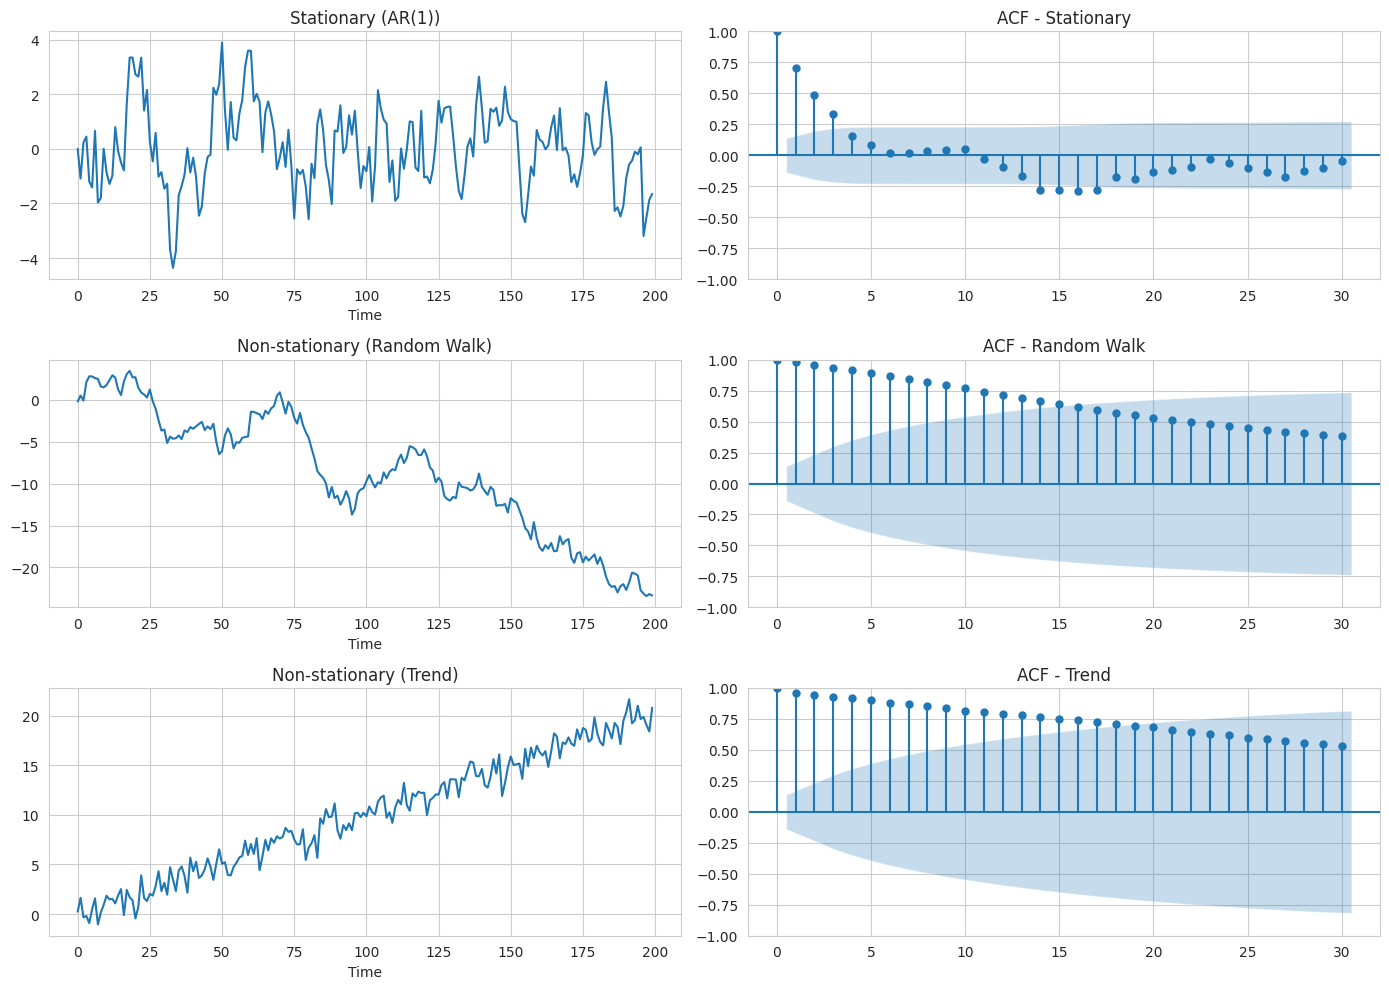

In [2]:
# 定常性と非定常性の例
np.random.seed(123)

n = 200
t = np.arange(n)

# Stationary process (AR(1))
phi = 0.7
y_stationary = np.zeros(n)
for i in range(1, n):
    y_stationary[i] = phi * y_stationary[i-1] + np.random.randn()

# Non-stationary process (random walk)
y_random_walk = np.cumsum(np.random.randn(n))

# Non-stationary process (trend)
y_trend = 0.1 * t + np.random.randn(n)

print("定常性と自己相関関数")
print("="*60)

# Plot
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Stationary
axes[0, 0].plot(t, y_stationary)
axes[0, 0].set_title('Stationary (AR(1))', fontsize=12)
axes[0, 0].set_xlabel('Time')

plot_acf(y_stationary, ax=axes[0, 1], lags=30)
axes[0, 1].set_title('ACF - Stationary', fontsize=12)

# Random walk
axes[1, 0].plot(t, y_random_walk)
axes[1, 0].set_title('Non-stationary (Random Walk)', fontsize=12)
axes[1, 0].set_xlabel('Time')

plot_acf(y_random_walk, ax=axes[1, 1], lags=30)
axes[1, 1].set_title('ACF - Random Walk', fontsize=12)

# Trend
axes[2, 0].plot(t, y_trend)
axes[2, 0].set_title('Non-stationary (Trend)', fontsize=12)
axes[2, 0].set_xlabel('Time')

plot_acf(y_trend, ax=axes[2, 1], lags=30)
axes[2, 1].set_title('ACF - Trend', fontsize=12)

plt.tight_layout()
plt.show()

In [3]:
# ADF検定（単位根検定）
print("ADF検定（定常性の検定）")
print("="*60)

for name, y in [('定常AR(1)', y_stationary), 
                ('ランダムウォーク', y_random_walk),
                ('トレンド', y_trend)]:
    result = adfuller(y)
    print(f"\n{name}:")
    print(f"  ADF統計量: {result[0]:.4f}")
    print(f"  p値: {result[1]:.4f}")
    if result[1] < 0.05:
        print("  → 定常 (H0を棄却)")
    else:
        print("  → 非定常 (H0を採択)")

ADF検定（定常性の検定）

定常AR(1):
  ADF統計量: -5.7383
  p値: 0.0000
  → 定常 (H0を棄却)

ランダムウォーク:
  ADF統計量: -0.1445
  p値: 0.9448
  → 非定常 (H0を採択)

トレンド:
  ADF統計量: 0.1386
  p値: 0.9686
  → 非定常 (H0を採択)


## 27.2 ARモデル

### AR(p)モデル
$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \epsilon_t$$

### 定常条件
特性方程式の根が単位円の外側

### ACFとPACF
- ACF: 指数的に減衰
- PACF: ラグpで切断

AR(2)モデル

真のパラメータ: φ_1 = 0.6, φ_2 = -0.3


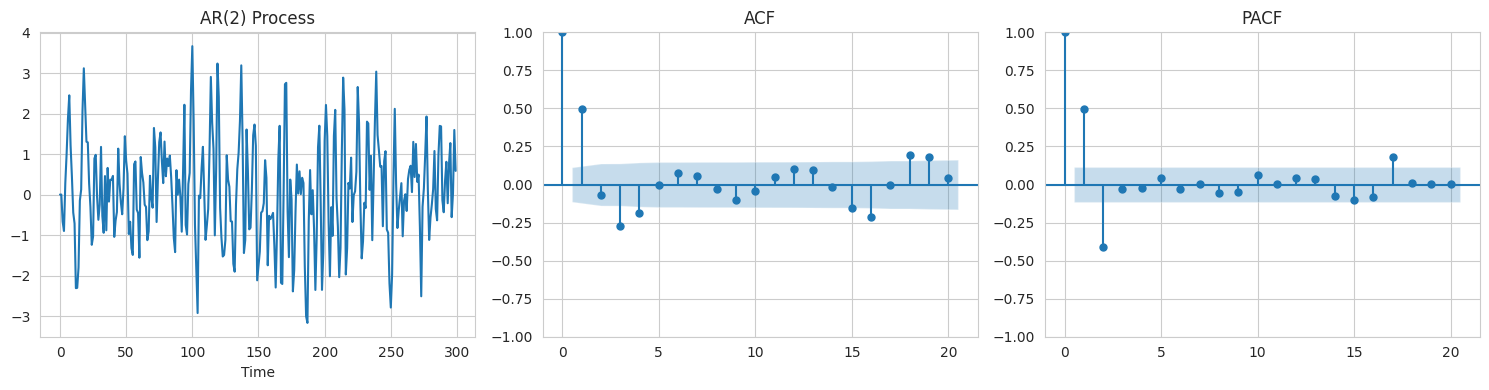


PACFがラグ2で切断 → AR(2)を示唆


In [4]:
# AR(2)モデル
np.random.seed(456)

n = 300
phi1, phi2 = 0.6, -0.3

y_ar2 = np.zeros(n)
for i in range(2, n):
    y_ar2[i] = phi1 * y_ar2[i-1] + phi2 * y_ar2[i-2] + np.random.randn()

print("AR(2)モデル")
print("="*60)
print(f"\n真のパラメータ: φ_1 = {phi1}, φ_2 = {phi2}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(y_ar2)
axes[0].set_title('AR(2) Process', fontsize=12)
axes[0].set_xlabel('Time')

plot_acf(y_ar2, ax=axes[1], lags=20)
axes[1].set_title('ACF', fontsize=12)

plot_pacf(y_ar2, ax=axes[2], lags=20)
axes[2].set_title('PACF', fontsize=12)

plt.tight_layout()
plt.show()

print("\nPACFがラグ2で切断 → AR(2)を示唆")

## 27.3 MAモデル

### MA(q)モデル
$$Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \cdots + \theta_q \epsilon_{t-q}$$

### 特徴
- 常に定常
- ACF: ラグqで切断
- PACF: 指数的に減衰

MA(2)モデル

真のパラメータ: θ_1 = 0.8, θ_2 = 0.4


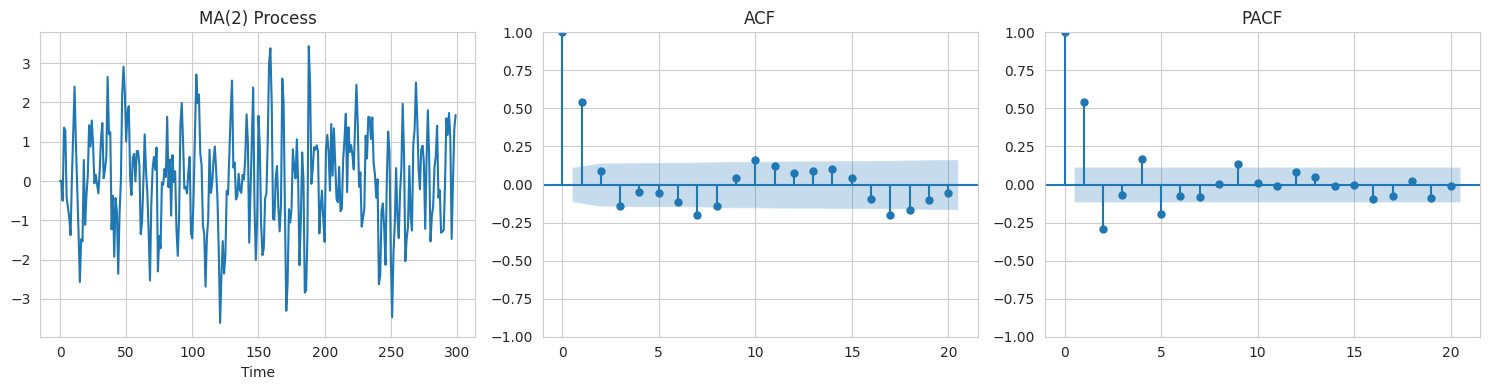


ACFがラグ2で切断 → MA(2)を示唆


In [5]:
# MA(2)モデル
np.random.seed(789)

n = 300
theta1, theta2 = 0.8, 0.4

epsilon = np.random.randn(n)
y_ma2 = np.zeros(n)
for i in range(2, n):
    y_ma2[i] = epsilon[i] + theta1 * epsilon[i-1] + theta2 * epsilon[i-2]

print("MA(2)モデル")
print("="*60)
print(f"\n真のパラメータ: θ_1 = {theta1}, θ_2 = {theta2}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(y_ma2)
axes[0].set_title('MA(2) Process', fontsize=12)
axes[0].set_xlabel('Time')

plot_acf(y_ma2, ax=axes[1], lags=20)
axes[1].set_title('ACF', fontsize=12)

plot_pacf(y_ma2, ax=axes[2], lags=20)
axes[2].set_title('PACF', fontsize=12)

plt.tight_layout()
plt.show()

print("\nACFがラグ2で切断 → MA(2)を示唆")

## 27.4 ARMAとARIMAモデル

### ARMA(p, q)モデル
$$Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}$$

### ARIMA(p, d, q)モデル
d階差分をとった系列にARMA(p, q)を適用

$$(1 - B)^d Y_t \sim \text{ARMA}(p, q)$$

ARIMA(1, 1, 1)モデル

真のパラメータ: φ_1 = 0.5, d = 1, θ_1 = 0.3


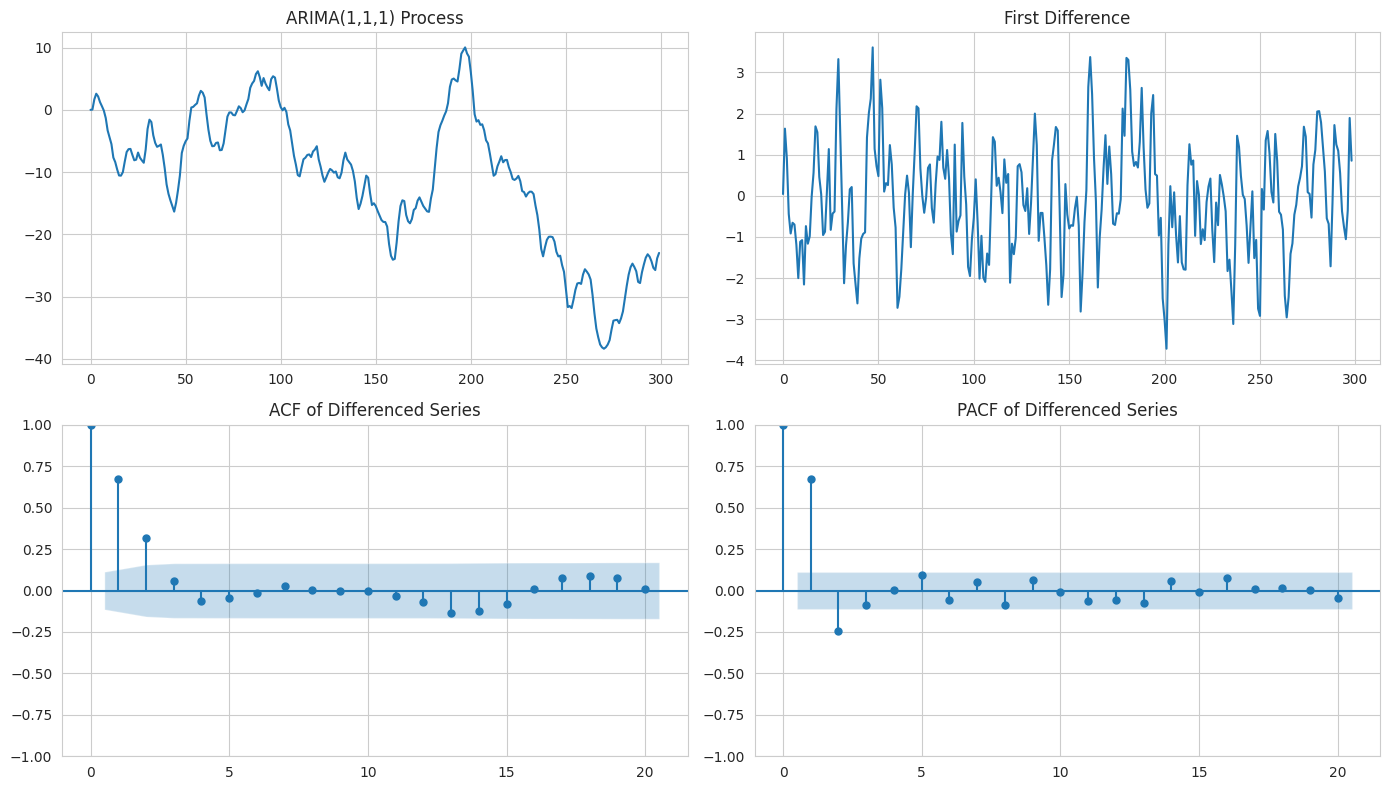

In [6]:
# ARIMA(1, 1, 1)モデル
np.random.seed(111)

n = 300
phi1 = 0.5
theta1 = 0.3

# Generate ARMA(1,1) for differences
epsilon = np.random.randn(n)
delta_y = np.zeros(n)
for i in range(1, n):
    delta_y[i] = phi1 * delta_y[i-1] + epsilon[i] + theta1 * epsilon[i-1]

# Cumulative sum to get ARIMA(1,1,1)
y_arima = np.cumsum(delta_y)

print("ARIMA(1, 1, 1)モデル")
print("="*60)
print(f"\n真のパラメータ: φ_1 = {phi1}, d = 1, θ_1 = {theta1}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(y_arima)
axes[0, 0].set_title('ARIMA(1,1,1) Process', fontsize=12)

axes[0, 1].plot(np.diff(y_arima))
axes[0, 1].set_title('First Difference', fontsize=12)

plot_acf(np.diff(y_arima), ax=axes[1, 0], lags=20)
axes[1, 0].set_title('ACF of Differenced Series', fontsize=12)

plot_pacf(np.diff(y_arima), ax=axes[1, 1], lags=20)
axes[1, 1].set_title('PACF of Differenced Series', fontsize=12)

plt.tight_layout()
plt.show()

## 27.5 Box-Jenkins法

### 手順
1. **同定**: ACF/PACFからp, d, qを決定
2. **推定**: パラメータを推定
3. **診断**: 残差を検討
4. **予測**: モデルを用いて予測

In [7]:
# Box-Jenkins法の実践
print("Box-Jenkins法")
print("="*60)

# Fit ARIMA model
model = ARIMA(y_arima, order=(1, 1, 1))
result = model.fit()

print("\nモデル推定結果:")
print(result.summary().tables[1])

print(f"\n真のパラメータ: φ_1 = {phi1}, θ_1 = {theta1}")
print(f"推定パラメータ: φ_1 = {result.arparams[0]:.3f}, θ_1 = {result.maparams[0]:.3f}")

Box-Jenkins法

モデル推定結果:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5337      0.069      7.759      0.000       0.399       0.668
ma.L1          0.2744      0.079      3.461      0.001       0.119       0.430
sigma2         0.9320      0.076     12.318      0.000       0.784       1.080

真のパラメータ: φ_1 = 0.5, θ_1 = 0.3
推定パラメータ: φ_1 = 0.534, θ_1 = 0.274


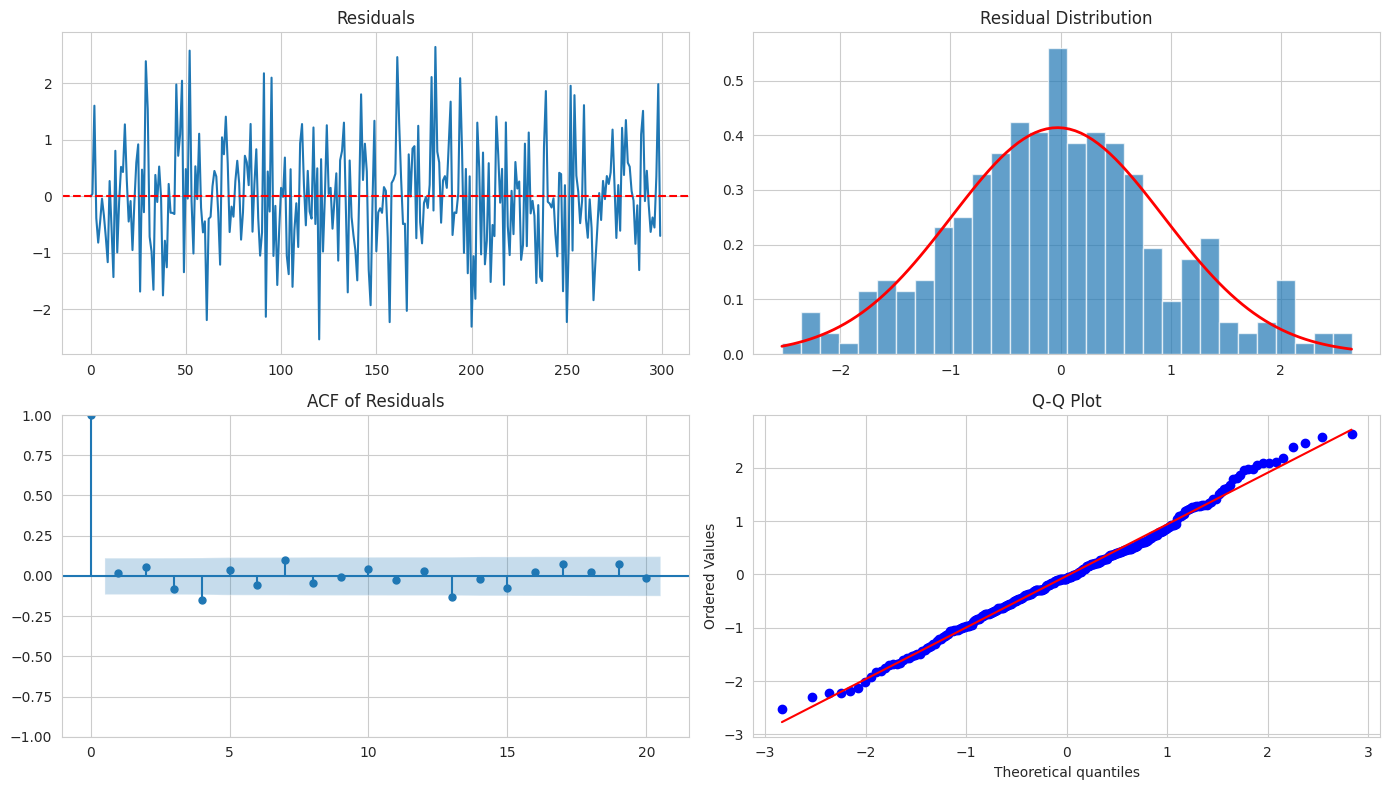


Ljung-Box検定 (lag=10):
統計量: 15.822
p値: 0.105


In [8]:
# 残差診断
residuals = result.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0, 0].plot(residuals)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals', fontsize=12)

# Histogram
axes[0, 1].hist(residuals, bins=30, density=True, alpha=0.7)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2)
axes[0, 1].set_title('Residual Distribution', fontsize=12)

# ACF of residuals
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title('ACF of Residuals', fontsize=12)

# Q-Q plot
stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"\nLjung-Box検定 (lag=10):")
print(f"統計量: {lb_test['lb_stat'].values[0]:.3f}")
print(f"p値: {lb_test['lb_pvalue'].values[0]:.3f}")

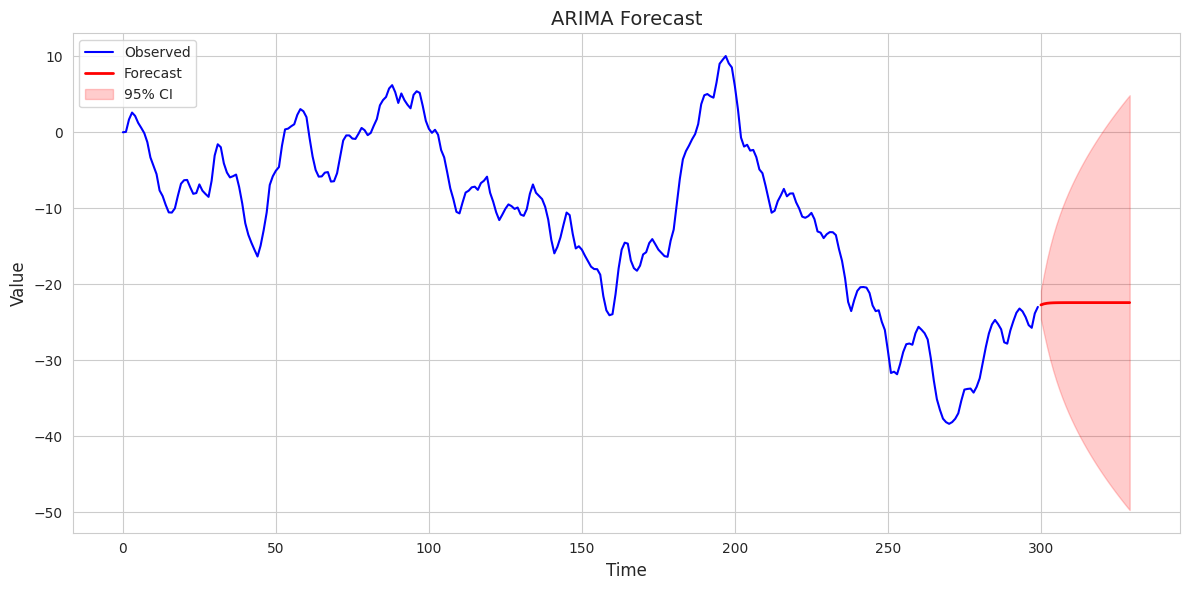

In [9]:
# 予測
n_forecast = 30
forecast = result.forecast(steps=n_forecast)
conf_int = result.get_forecast(steps=n_forecast).conf_int()

fig, ax = plt.subplots(figsize=(12, 6))

# Historical data
ax.plot(range(len(y_arima)), y_arima, 'b-', label='Observed')

# Forecast
forecast_index = range(len(y_arima), len(y_arima) + n_forecast)
ax.plot(forecast_index, forecast, 'r-', linewidth=2, label='Forecast')

# Confidence interval
ax.fill_between(forecast_index, conf_int[:, 0], conf_int[:, 1], 
                color='red', alpha=0.2, label='95% CI')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('ARIMA Forecast', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 27.6 スペクトル分析

### 基本概念
時系列を周波数成分に分解

### スペクトル密度
$$f(\omega) = \frac{1}{2\pi} \sum_{h=-\infty}^{\infty} \gamma_h e^{-i\omega h}$$

自己共分散関数のフーリエ変換

### ピリオドグラム
スペクトル密度の推定量

スペクトル分析


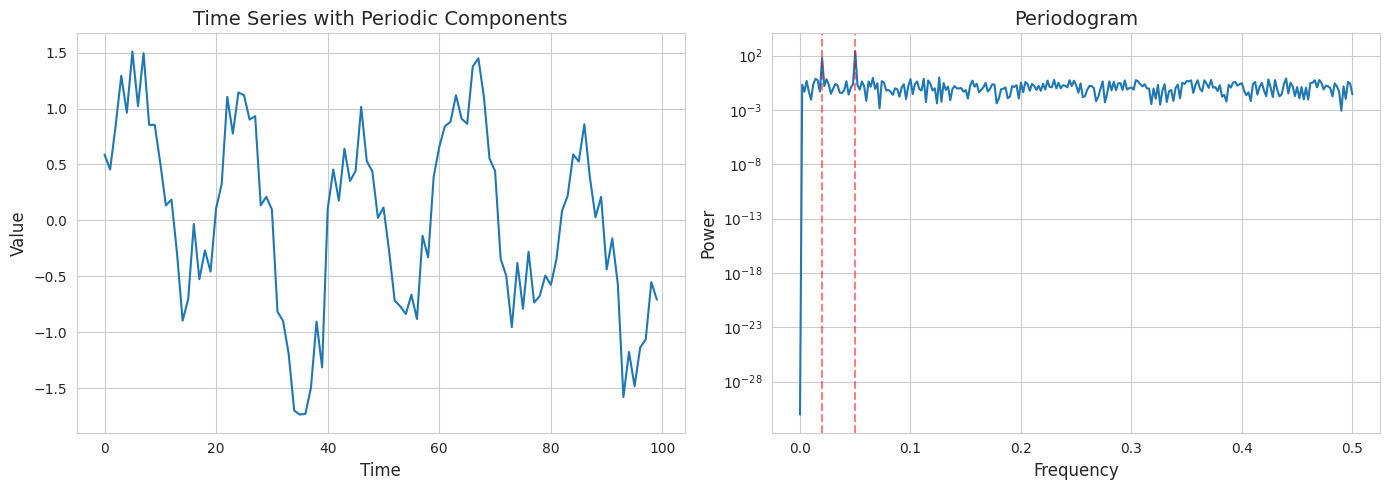


真の周期: 20 (f = 0.05), 50 (f = 0.02)


In [10]:
# スペクトル分析
np.random.seed(222)

# Generate data with periodic component
n = 500
t = np.arange(n)

# Signal with two frequencies
y_periodic = (np.sin(2 * np.pi * t / 20) + 
              0.5 * np.sin(2 * np.pi * t / 50) + 
              0.3 * np.random.randn(n))

print("スペクトル分析")
print("="*60)

# Calculate periodogram
frequencies, periodogram = signal.periodogram(y_periodic, fs=1.0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t[:100], y_periodic[:100])
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Time Series with Periodic Components', fontsize=14)

axes[1].semilogy(frequencies, periodogram)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('Power', fontsize=12)
axes[1].set_title('Periodogram', fontsize=14)

# Mark peaks
peaks = [1/20, 1/50]  # True frequencies
for peak in peaks:
    axes[1].axvline(peak, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n真の周期: 20 (f = 0.05), 50 (f = 0.02)")

## 27.7 練習問題

### 問題1
AR(1)とMA(1)モデルのACFの違いを説明せよ。

### 問題2
ARIMAモデルで差分をとる（dを増やす）のはどのような場合か。

### 問題3
残差のLjung-Box検定のp値が0.01の場合、どう解釈すべきか。

問題1: AR(1)とMA(1)のACF

【AR(1): Y_t = φY_{t-1} + ε_t】
ACF: ρ_h = φ^h
→ 指数的に減衰（|φ| < 1のとき）
→ 理論上は無限に続く

【MA(1): Y_t = ε_t + θε_{t-1}】
ACF: ρ_1 = θ/(1+θ²), ρ_h = 0 (h > 1)
→ ラグ1で切断
→ ラグ2以降は0

【識別への応用】
・ACFが緩やかに減衰 → AR
・ACFが急に切断 → MA
・PACFも合わせて確認



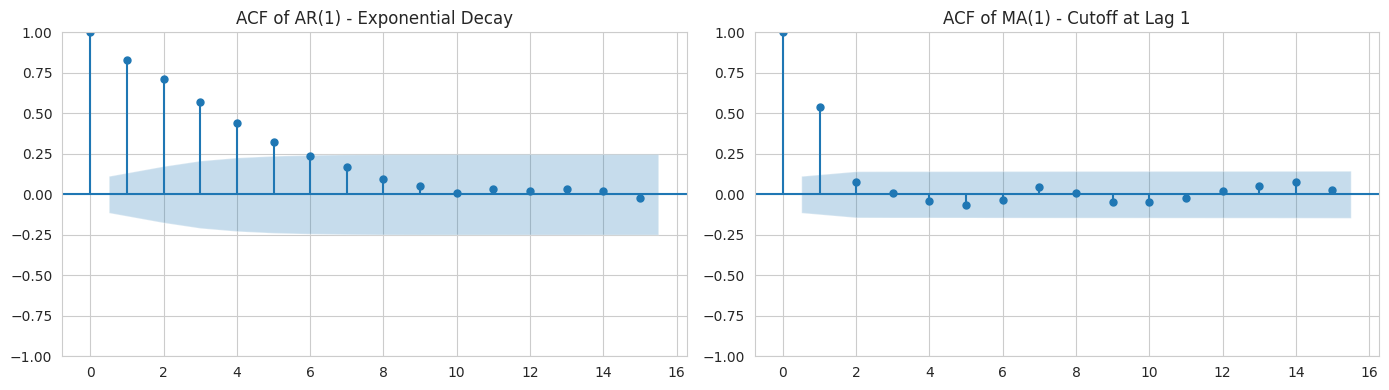

In [11]:
# 問題1の解答
print("問題1: AR(1)とMA(1)のACF")
print("="*60)

print("""
【AR(1): Y_t = φY_{t-1} + ε_t】
ACF: ρ_h = φ^h
→ 指数的に減衰（|φ| < 1のとき）
→ 理論上は無限に続く

【MA(1): Y_t = ε_t + θε_{t-1}】
ACF: ρ_1 = θ/(1+θ²), ρ_h = 0 (h > 1)
→ ラグ1で切断
→ ラグ2以降は0

【識別への応用】
・ACFが緩やかに減衰 → AR
・ACFが急に切断 → MA
・PACFも合わせて確認
""")

# Visualize
np.random.seed(333)
n = 300

# AR(1)
y_ar = np.zeros(n)
for i in range(1, n):
    y_ar[i] = 0.8 * y_ar[i-1] + np.random.randn()

# MA(1)
eps = np.random.randn(n)
y_ma = np.zeros(n)
for i in range(1, n):
    y_ma[i] = eps[i] + 0.8 * eps[i-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_ar, ax=axes[0], lags=15)
axes[0].set_title('ACF of AR(1) - Exponential Decay', fontsize=12)
plot_acf(y_ma, ax=axes[1], lags=15)
axes[1].set_title('ACF of MA(1) - Cutoff at Lag 1', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# 問題2の解答
print("問題2: 差分をとる場合")
print("="*60)

print("""
【差分が必要な場合】
1. 単位根（ランダムウォーク）
   - ACFが非常にゆっくり減衰
   - ADF検定で非定常

2. トレンド
   - 平均が時間とともに変化
   - 1回差分で除去可能

3. 季節性（季節差分）
   - 周期sの季節パターン
   - (1 - B^s)Y_t で除去

【注意点】
・過度の差分は避ける（過差分）
・通常 d ≤ 2
・差分後の系列が定常になることを確認
""")

問題2: 差分をとる場合

【差分が必要な場合】
1. 単位根（ランダムウォーク）
   - ACFが非常にゆっくり減衰
   - ADF検定で非定常

2. トレンド
   - 平均が時間とともに変化
   - 1回差分で除去可能

3. 季節性（季節差分）
   - 周期sの季節パターン
   - (1 - B^s)Y_t で除去

【注意点】
・過度の差分は避ける（過差分）
・通常 d ≤ 2
・差分後の系列が定常になることを確認



In [13]:
# 問題3の解答
print("問題3: Ljung-Box検定の解釈")
print("="*60)

print("""
【p値 = 0.01 の意味】
帰無仮説: 残差は無相関（白色雑音）
p = 0.01 < 0.05 → 帰無仮説を棄却

【解釈】
残差に自己相関が残っている
→ モデルが不適切

【対処法】
1. モデル次数の変更
   - pまたはqを増やす

2. 差分次数の再検討
   - dを変更

3. 季節成分の追加
   - SARIMAモデルを検討

4. 他のモデルを検討
   - GARCH（分散の時変）
   - 状態空間モデル
""")

問題3: Ljung-Box検定の解釈

【p値 = 0.01 の意味】
帰無仮説: 残差は無相関（白色雑音）
p = 0.01 < 0.05 → 帰無仮説を棄却

【解釈】
残差に自己相関が残っている
→ モデルが不適切

【対処法】
1. モデル次数の変更
   - pまたはqを増やす

2. 差分次数の再検討
   - dを変更

3. 季節成分の追加
   - SARIMAモデルを検討

4. 他のモデルを検討
   - GARCH（分散の時変）
   - 状態空間モデル



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---